In [30]:
import json
import pandas as pd
import numpy as np
import os
import random 
import glob
from tqdm import tqdm
import uuid
from PIL import Image
from collections import Counter
import sys
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [31]:
df_multiple = pd.read_csv('India data dict - MP_India.csv')
df_multiple.drop(columns = ['total kernels'], inplace=True)
MP_folder = "/media/new_volumn/MP_India_Cleaned1_Hovernet/"

In [32]:
df_multiple.columns

Index(['state', 'city', 'mandi', 'mill', 'breed', 'original location',
       'location', 'image_num', 'date', 'normal kernels'],
      dtype='object')

In [33]:
df_multiple['breed'].unique(), len(df_multiple['breed'].unique())

(array(['Pusa 1509 Basmati', 'Pusa 1121 Basmati', 'Pusa',
        'Pusa 1718 Basmati', 'Pusa 1401 Basmati', 'Sharbati Rice',
        'Sugandha Basmati', 'PB1 Basmati', 'TAJ'], dtype=object),
 9)

In [34]:
df_multiple['folder'] = MP_folder+df_multiple['location'].str.split(' > ').str[-1]

In [35]:
df_multiple

,state,city,mandi,mill,breed,original location,location,image_num,date,normal kernels,folder
0,Haryana,Sonipat,Ramraaj,HRL Food,Pusa 1509 Basmati,MP_India > 000001,MP_India > 000001,14,30/09/2024,4776,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
1,Haryana,Sonipat,Jahangirpur-1,HRL Food,Pusa 1509 Basmati,MP_India > 000002,MP_India > 000002,14,30/09/2024,3532,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
2,Haryana,Sonipat,Jahangirpur-2,HRL Food,Pusa 1509 Basmati,MP_India > 000003,MP_India > 000003,16,01/10/2024,4388,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
3,Haryana,Sonipat,Sonipat-1,HRL Food,Pusa 1509 Basmati,MP_India > 000004,MP_India > 000004,12,01/10/2024,3081,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
4,Haryana,Sonipat,Sonipat-2,HRL Food,Pusa 1509 Basmati,MP_India > 000005,MP_India > 000005,14,02/10/2024,2866,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
...,...,...,...,...,...,...,...,...,...,...,...
74,-,Gannaur,Gannaur,SUNRISE,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000075,12,14/01/2025,2840,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
75,-,Panipat,Panipat,SUNRISE,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000076,10,14/01/2025,2413,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
76,-,Samalkha,Samalkha,SUNRISE,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000077,12,14/01/2025,3012,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
77,-,Gannaur,Gannaur,VEER,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000078,12,17/01/2025,2893,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...


In [36]:
df_multiple.groupby('breed')['normal kernels'].sum(), df_multiple['normal kernels'].sum(), df_multiple.groupby('breed')['normal kernels'].sum().median()

(breed
 PB1 Basmati           13669
 Pusa                  12010
 Pusa 1121 Basmati     56437
 Pusa 1401 Basmati     37021
 Pusa 1509 Basmati    165797
 Pusa 1718 Basmati     33114
 Sharbati Rice         26713
 Sugandha Basmati      22035
 TAJ                   14865
 Name: normal kernels, dtype: int64,
 np.int64(381661),
 np.float64(26713.0))

In [37]:
normal_kernels_per_breed = (df_multiple['normal kernels'].sum()) / (len(df_multiple['breed'].unique()))
lower_bound = min(df_multiple.groupby('breed')['normal kernels'].sum())
normal_kernels_per_breed, lower_bound

(np.float64(42406.77777777778), 12010)

In [38]:
def load_npz_file(file_path):
    """Load .npz file and return kernel count."""
    try:
        data = np.load(file_path)
        kernels = data['kernel_pics']  # Assuming the kernels are stored in 'kernel_pics' key
        return kernels.shape[0]  # Return total kernel count
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return 0  # Return 0 if file loading fails
    
def create_balanced_dataset(df):
    """Create a balanced dataset with equal kernel count for each breed."""
    final_df = pd.DataFrame()
    # Total target kernel count
    total_kernels = df_multiple['normal kernels'].sum()
    num_available_classes = len(df['breed'].unique())
    main_kernels = total_kernels / num_available_classes  # Equal kernel count for main classes

    
    def sample_folders_for_class(df_class, target_kernels):
        sampled_df = pd.DataFrame()
        cumulative_kernels = 0
        npz_files = []
        location_files = []
        
        # Sample folder paths corresponding to the breed class
        unique_folders = df_class['folder'].drop_duplicates().sample(frac=1).tolist()

        # Loop through each folder and sample npz files
        for folder in unique_folders:
            folder_rows = df_class[df_class['folder'] == folder]
            # folder_rows.drop
            folder_path = folder_rows['folder'].iloc[0]  # Get the full folder path
            all_npz_files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]  # List all npz files
            random.seed(42)  # Set seed for reproducibility
            random.shuffle(all_npz_files) # shuffle the files

            # Add npz files to the list and update kernel count
            for npz_file in all_npz_files:
                npz_file_path = os.path.join(folder_path, npz_file)
                kernels_in_file = load_npz_file(npz_file_path)
                cumulative_kernels += kernels_in_file
                npz_files.append(npz_file_path)
                location_files.append(npz_file)

                # Add new row with npz file path and kernel count
                new_row = folder_rows.copy()
                new_row['location'] = npz_file_path  # Set location to npz file path
                new_row['location_file'] = npz_file  # Add npz file name to location_file column
                new_row['normal kernels'] = kernels_in_file  # Add kernel count
                sampled_df = pd.concat([sampled_df, new_row], ignore_index=True)

                if cumulative_kernels >= target_kernels:
                    break  # Stop when the target kernel count is reached

            if cumulative_kernels >= target_kernels:
                break  # Stop after reaching the kernel target

        return sampled_df, cumulative_kernels, npz_files
    
    for breed in df['breed'].unique():
        breed_df = df[df['breed'] == breed]
        total_normal_kernels = breed_df['normal kernels'].sum()
        target_kernels = main_kernels if total_normal_kernels >= main_kernels else total_normal_kernels # Sample main kernels if available
        # Sample folders for the breed class
        print(f"Sampling {target_kernels} kernels for {breed}")
        sampled_df, cumulative_kernels, npz_files = sample_folders_for_class(breed_df, target_kernels)
        
        final_df = pd.concat([final_df, sampled_df], ignore_index=True)
    
    return final_df

In [39]:
df_balanced = create_balanced_dataset(df_multiple)


Sampling 42406.77777777778 kernels for Pusa 1509 Basmati
Sampling 42406.77777777778 kernels for Pusa 1121 Basmati
Sampling 12010 kernels for Pusa
Sampling 33114 kernels for Pusa 1718 Basmati
Sampling 37021 kernels for Pusa 1401 Basmati
Sampling 26713 kernels for Sharbati Rice
Sampling 22035 kernels for Sugandha Basmati
Sampling 13669 kernels for PB1 Basmati
Sampling 14865 kernels for TAJ


In [40]:
print(df_balanced.groupby('breed')['normal kernels'].sum()), df_balanced['normal kernels'].sum()

breed
PB1 Basmati          13669
Pusa                 12010
Pusa 1121 Basmati    42478
Pusa 1401 Basmati    37023
Pusa 1509 Basmati    42498
Pusa 1718 Basmati    33114
Sharbati Rice        26714
Sugandha Basmati     22035
TAJ                  14862
Name: normal kernels, dtype: int64


(None, np.int64(244403))

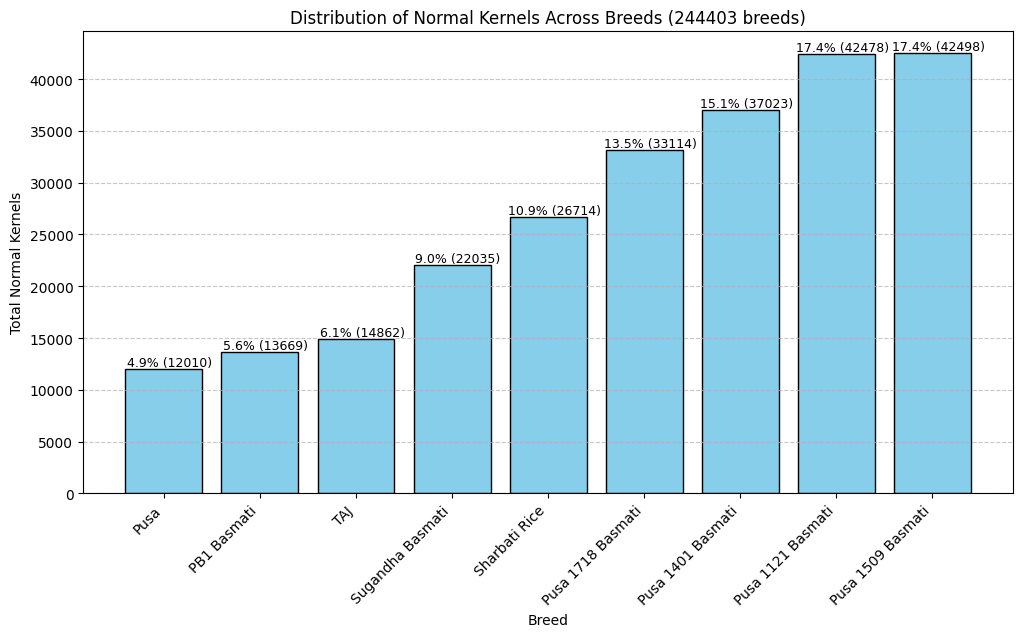

In [41]:
df_plot = df_balanced

# Group by breed and sum normal kernels
breed_counts = df_plot.groupby('breed')['normal kernels'].sum().sort_values()

# Calculate percentages
total_kernels = breed_counts.sum()
breed_percentages = (breed_counts / total_kernels) * 100

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(breed_counts.index, breed_counts, color='skyblue', edgecolor='black')

# Add text labels (showing both percentage and total count) on top of bars
for bar, count, perc in zip(bars, breed_counts, breed_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"   {perc:.1f}% ({count})",  # Show percentage + count
             ha='center', va='bottom', fontsize=9, color='black')

# Labels and title
plt.xlabel("Breed")
plt.ylabel("Total Normal Kernels")
plt.title(f"Distribution of Normal Kernels Across Breeds ({df_plot['normal kernels'].sum()} breeds)")
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [ ]:
SSLv2_folder = "/media/new_volumn/SIMDINOV2_EASYRICE/SSLv2/"
os.makedirs(SSLv2_folder, exist_ok=True)
output_file = f"{SSLv2_folder}/SSLv2_India_Cleaned1_Hovernet_data.csv"


In [ ]:

# df_balanced.to_csv(output_file, index=False)

# Divide into train and test set

In [42]:
df_balanced = pd.read_csv(output_file)

In [18]:
train_df, test_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['breed'], random_state=42)

# Reset indexes
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [19]:
train_df.groupby('breed')['normal kernels'].sum()

breed
PB1 Basmati          10751
Pusa                  9727
Pusa 1121 Basmati    33941
Pusa 1401 Basmati    30257
Pusa 1509 Basmati    34005
Pusa 1718 Basmati    25517
Sharbati Rice        21484
Sugandha Basmati     17966
TAJ                  12089
Name: normal kernels, dtype: int64

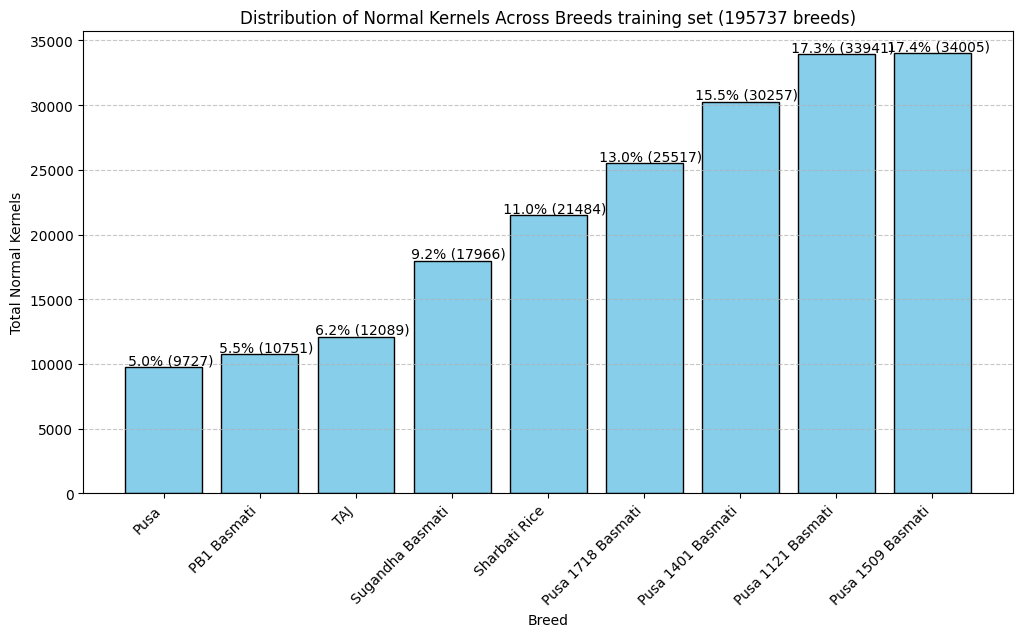

In [20]:
df_plot = train_df

# Group by breed and sum normal kernels
breed_counts = df_plot.groupby('breed')['normal kernels'].sum().sort_values()

# Calculate percentages
total_kernels = breed_counts.sum()
breed_percentages = (breed_counts / total_kernels) * 100

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(breed_counts.index, breed_counts, color='skyblue', edgecolor='black')

# Add text labels (showing both percentage and total count) on top of bars
for bar, count, perc in zip(bars, breed_counts, breed_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"   {perc:.1f}% ({count})",  # Show percentage + count
             ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Breed")
plt.ylabel("Total Normal Kernels")
plt.title(f"Distribution of Normal Kernels Across Breeds training set ({df_plot['normal kernels'].sum()} breeds)")
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [ ]:
train_file = f"{SSLv2_folder}/SSLv2_India_Cleaned1_Hovernet_train.csv"
test_file = f"{SSLv2_folder}/SSLv2_India_Cleaned1_Hovernet_test.csv"


In [ ]:

# train_df.to_csv(train_file, index=False)
# test_df.to_csv(test_file, index=False)

In [44]:
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

In [58]:
India_Images_folder = "/media/new_volumn/SIMDINOV2_EASYRICE/images_MP_India/"

def save_images(df, split):
    """Save images into train adn test folders from the dataframe."""
    for i, row in tqdm(df.iterrows(), total=len(df)):
        breed = row['breed']
        output_dir = f"{India_Images_folder}/{split}/{breed}/"
        os.makedirs(output_dir, exist_ok=True) 

        images = np.load(row['location'])
        kernels = images['kernel_pics'].astype(np.uint8)
        
        # Save each kernel as an image
        for i, kernel in enumerate(kernels):
            img = Image.fromarray((kernel).astype(np.uint8)) 
            img.save(f"{output_dir}/hovernet_{row['location_file'].split('.npz')[0]}_{i}.png")

In [59]:
save_images(train_df, "train")
save_images(test_df, "test")

100%|██████████| 118/118 [01:36<00:00,  1.22it/s]
